# Experiment 1: Model Comparison — KMeans vs GMM vs DP-GMM

**Compares three clustering approaches on the Iris dataset:**
- KMeans (fixed k=3)
- Gaussian Mixture Model (fixed n_components=3)
- Dirichlet Process GMM (BayesianGaussianMixture, auto-infers clusters)

**Metrics:** Adjusted Rand Index, Silhouette Score, Number of Effective Clusters.

**Reference:** Görür & Rasmussen (2010). "Dirichlet Process Gaussian Mixture Models: Choice of the Base Distribution." JCST 25(4), 615–626.

## 1. Imports & Setup

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Paths
PLOTS_DIR = os.path.join('..', 'results', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

## 2. Load & Prepare Data

In [10]:
iris = load_iris()
X_full = iris.data
y_true = iris.target
feature_names = iris.feature_names

# Use first 2 features for visualization; full features for metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
X_vis = X_scaled[:, :2]

print(f"Dataset: Iris")
print(f"Samples: {X_full.shape[0]}, Features: {X_full.shape[1]}")
print(f"Classes: {len(np.unique(y_true))} ({', '.join(iris.target_names)})")

Dataset: Iris
Samples: 150, Features: 4
Classes: 3 (setosa, versicolor, virginica)


## 3. Fit Models

### 3.1 KMeans (k=3, manually specified)

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
print(f"KMeans: {len(np.unique(labels_km))} clusters (k=3, manually set)")

KMeans: 3 clusters (k=3, manually set)


### 3.2 Standard GMM (n_components=3, manually specified)

In [12]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels_gmm = gmm.predict(X_scaled)
print(f"GMM: {len(np.unique(labels_gmm))} clusters (n_components=3, manually set)")

GMM: 3 clusters (n_components=3, manually set)


### 3.3 DP-GMM (Bayesian GMM with Dirichlet Process prior)

The key point: we set `n_components=10` as an **UPPER BOUND**.
The model **AUTOMATICALLY** determines how many clusters to use.

In [13]:
dpgmm = BayesianGaussianMixture(
    n_components=10,                    # upper bound on clusters
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=1.0,     # concentration α
    max_iter=500,
    random_state=42,
    init_params='kmeans'
)
dpgmm.fit(X_scaled)
labels_dp = dpgmm.predict(X_scaled)

# Count effective clusters
def count_effective_clusters_by_weight(model, threshold=0.01):
    """Count clusters with weight > threshold (standard for DP-GMM)."""
    return int(np.sum(model.weights_ > threshold))

n_eff_dpgmm = count_effective_clusters_by_weight(dpgmm)
n_unique_dpgmm = len(np.unique(labels_dp))

print(f"DP-GMM effective clusters (weight > 1%): {n_eff_dpgmm}")
print(f"DP-GMM unique labels assigned: {n_unique_dpgmm}")

DP-GMM effective clusters (weight > 1%): 6
DP-GMM unique labels assigned: 6


## 4. Comparison Table

In [14]:
results = []
for name, labels, n_cl in [
    ('KMeans', labels_km, 3),
    ('GMM', labels_gmm, 3),
    ('DP-GMM', labels_dp, n_eff_dpgmm)
]:
    ari = adjusted_rand_score(y_true, labels)
    sil = silhouette_score(X_scaled, labels)
    results.append((name, n_cl, ari, sil))

print("=" * 65)
print("EXPERIMENT 1: Model Comparison on Iris Dataset")
print("=" * 65)
print(f"{'Model':<12} {'Clusters':>10} {'ARI':>10} {'Silhouette':>12}")
print("-" * 46)
for name, n_cl, ari, sil in results:
    cluster_str = str(n_cl) if name != 'DP-GMM' else f"{n_cl} (auto)"
    print(f"{name:<12} {cluster_str:>10} {ari:>10.4f} {sil:>12.4f}")
print("-" * 46)
print("\nARI = Adjusted Rand Index (1.0 = perfect match with true labels)")
print("Silhouette Score: higher is better (-1 to 1)")
print(f"\n💡 Key insight: DP-GMM does NOT require specifying k beforehand!")
print(f"   KMeans and GMM needed k=3 to be manually specified.")

EXPERIMENT 1: Model Comparison on Iris Dataset
Model          Clusters        ARI   Silhouette
----------------------------------------------
KMeans                3     0.6201       0.4599
GMM                   3     0.5165       0.4751
DP-GMM         6 (auto)     0.5427       0.2219
----------------------------------------------

ARI = Adjusted Rand Index (1.0 = perfect match with true labels)
Silhouette Score: higher is better (-1 to 1)

💡 Key insight: DP-GMM does NOT require specifying k beforehand!
   KMeans and GMM needed k=3 to be manually specified.


## 5. Cluster Visualization

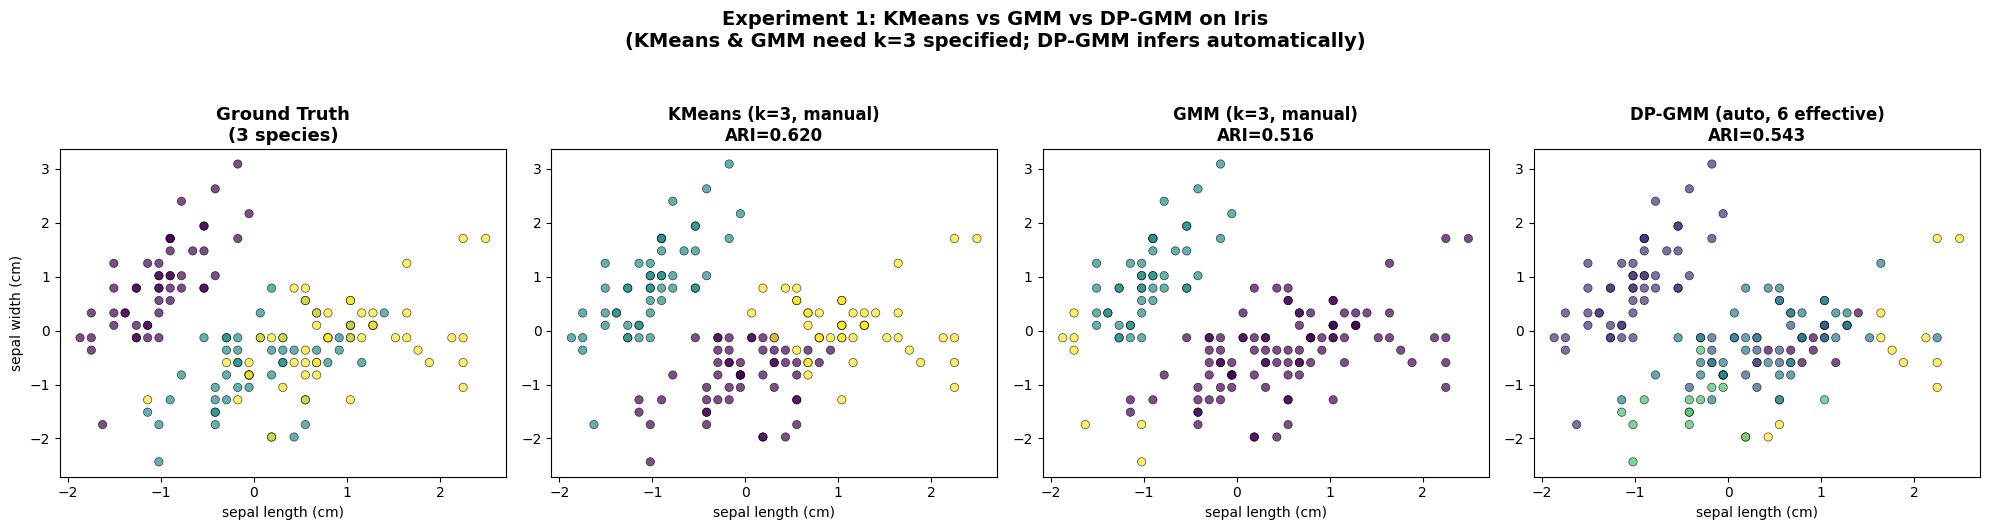

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Ground truth
axes[0].scatter(X_vis[:, 0], X_vis[:, 1], c=y_true,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0].set_title('Ground Truth\n(3 species)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(feature_names[0])
axes[0].set_ylabel(feature_names[1])

# KMeans
axes[1].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_km,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[1].set_title(f'KMeans (k=3, manual)\nARI={results[0][2]:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(feature_names[0])

# GMM
axes[2].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_gmm,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[2].set_title(f'GMM (k=3, manual)\nARI={results[1][2]:.3f}',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel(feature_names[0])

# DP-GMM
axes[3].scatter(X_vis[:, 0], X_vis[:, 1], c=labels_dp,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.5)
axes[3].set_title(f'DP-GMM (auto, {n_eff_dpgmm} effective)\n'
                  f'ARI={results[2][2]:.3f}', fontsize=12, fontweight='bold')
axes[3].set_xlabel(feature_names[0])

plt.suptitle('Experiment 1: KMeans vs GMM vs DP-GMM on Iris\n'
             '(KMeans & GMM need k=3 specified; DP-GMM infers automatically)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'exp1_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. DP-GMM Component Weights

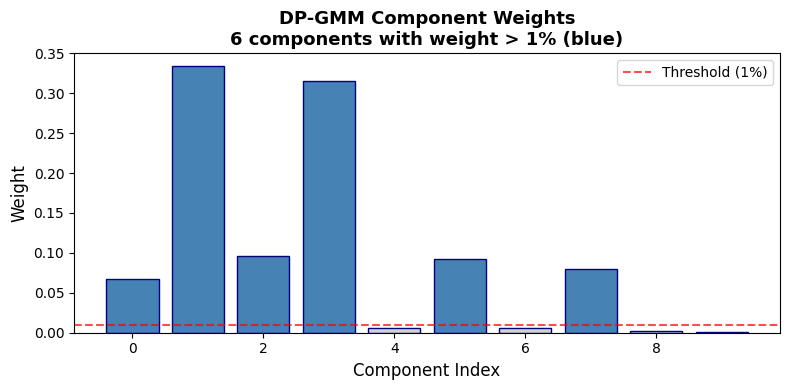


🏁 Experiment 1 complete.


In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
weights = dpgmm.weights_
colors = ['steelblue' if w > 0.01 else 'lightgray' for w in weights]
ax.bar(range(len(weights)), weights, color=colors, edgecolor='navy')
ax.set_xlabel('Component Index', fontsize=12)
ax.set_ylabel('Weight', fontsize=12)
ax.set_title(f'DP-GMM Component Weights\n'
             f'{n_eff_dpgmm} components with weight > 1% (blue)',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.01, color='red', linestyle='--', alpha=0.7, label='Threshold (1%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'exp1_dpgmm_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n🏁 Experiment 1 complete.")